# Conv1D + Multi-Head Attention -- Clasificacion de 3 Clases con Walk-Forward Validation

Recorre los resultados de `train_walkforward.py`: la arquitectura hibrida
Conv1D + Multi-Head Attention (`model_conv_attention.py`) entrenada para
clasificar la direccion de la siguiente vela de BTCUSDT en 3 clases
(**Bajista / Neutro / Alcista**), evaluada con **Walk-Forward
Cross-Validation** (5 folds, ventana de entrenamiento expansiva) sobre
velas reales de Binance, con una metrica final que descuenta **costos de
transaccion + slippage (10 bps por cambio de posicion)** -- no solo
accuracy/F1, que no dicen nada sobre si la senal sobrevive el costo real de
operarla.

Requiere haber corrido antes:
```
python fetch_binance_data.py
python train_walkforward.py
```


In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

REPORTS_DIR = Path("outputs/reports")
FIGURES_DIR = Path("outputs/figures")

CLASS_NAMES = ["Bajista", "Neutro", "Alcista"]

plt.style.use("seaborn-v0_8-darkgrid")
COLOR_TRAIN = "#4C72B0"
COLOR_VAL = "#DD8452"
COLOR_ACC = "#55A868"
COLOR_GROSS = "#4C72B0"
COLOR_NET = "#C44E52"

## 1. Resumen walk-forward

5 folds de origen rodante (rolling-origin): la ventana de entrenamiento se
expande en cada fold (nunca se descarta historia pasada), y cada fold
evalua sobre un bloque de test estrictamente posterior a todo lo usado
para entrenar y validar ese fold -- el esquema riguroso que evita que un
solo split cronologico (usado en `train_classifier.py`) dependa de qué
tan representativo resulte ser, por azar, ese único tramo de test.

In [2]:
with open(REPORTS_DIR / "walkforward_summary.json") as f:
    summary = json.load(f)

print(f"Folds: {summary['n_folds']}  |  Ventana de secuencia: {summary['window_length']} velas")
print(f"Costo total por trade (comision + slippage): {summary['total_cost_bps']:.0f} bps\n")

folds_df = pl.DataFrame(summary["folds"])
folds_df.select(["fold", "n_train", "n_test", "test_accuracy", "test_f1_macro", "n_trades", "net_return_total"])

Folds: 5  |  Ventana de secuencia: 24 velas
Costo total por trade (comision + slippage): 10 bps



fold,n_train,n_test,test_accuracy,test_f1_macro,n_trades,net_return_total
i64,i64,i64,f64,f64,i64,f64
1,8480,1995,0.390977,0.35815,726,-1.172761
2,10176,1995,0.402005,0.40091,714,-1.217206
3,11871,1995,0.383459,0.378349,698,-1.195358
4,13567,1995,0.396992,0.377727,796,-0.990895
5,15263,1998,0.380881,0.371494,773,-1.152523


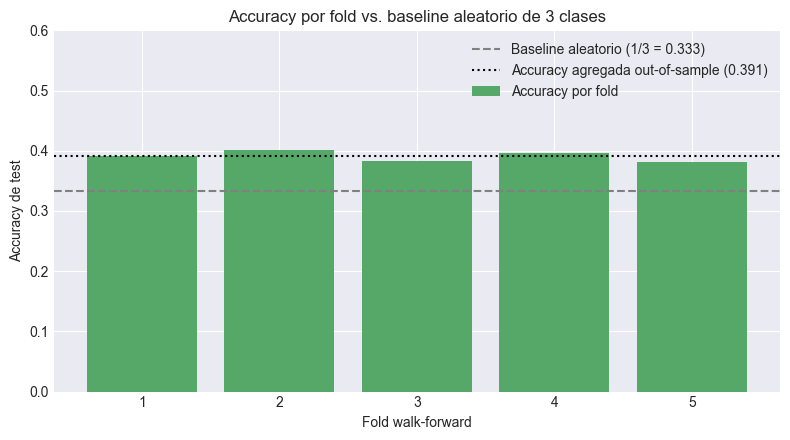

In [3]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(folds_df["fold"], folds_df["test_accuracy"], color=COLOR_ACC, label="Accuracy por fold")
ax.axhline(summary["random_baseline_accuracy"], color="gray", linestyle="--",
           label=f"Baseline aleatorio (1/3 = {summary['random_baseline_accuracy']:.3f})")
ax.axhline(summary["overall_accuracy"], color="black", linestyle=":",
           label=f"Accuracy agregada out-of-sample ({summary['overall_accuracy']:.3f})")
ax.set_xlabel("Fold walk-forward")
ax.set_ylabel("Accuracy de test")
ax.set_title("Accuracy por fold vs. baseline aleatorio de 3 clases")
ax.set_ylim(0, 0.6)
ax.legend()
fig.tight_layout()
plt.show()

## 2. Curvas de aprendizaje (fold 5 -- el de mayor historia de entrenamiento)

El ultimo fold entrena con ~77% de los datos disponibles (la ventana
walk-forward ya se expandió al máximo) y es el que más se acerca a un
despliegue real, así que sus curvas de entrenamiento son las que se
inspeccionan en detalle.

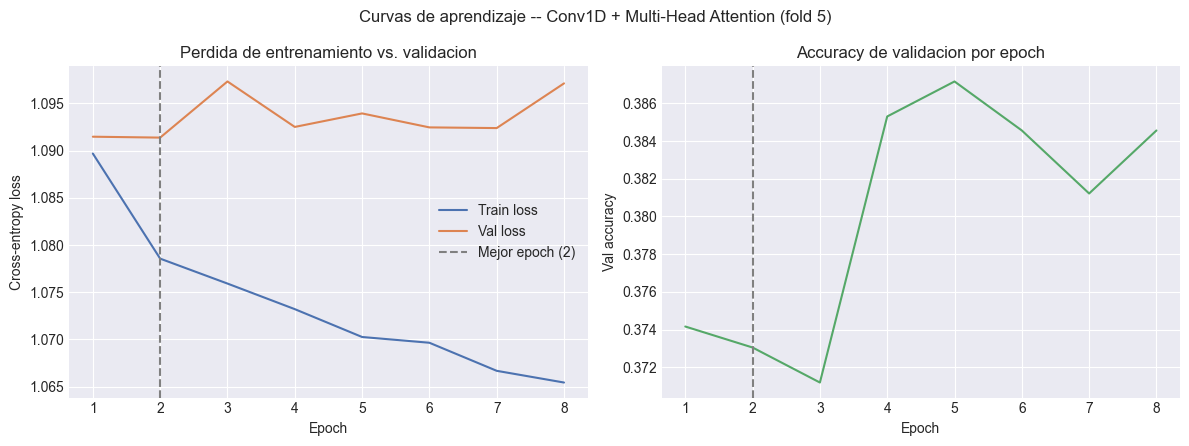

El val_loss deja de mejorar despues del epoch 2: el train_loss sigue bajando (el modelo sigue ajustandose) mientras el val_loss se estanca/sube -- el patron clasico de sobreajuste que el early stopping (paciencia=6 epochs) esta especificamente ahi para cortar.


In [4]:
history = pl.read_csv(REPORTS_DIR / "walkforward_last_fold_history.csv")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(history["epoch"], history["train_loss"], color=COLOR_TRAIN, label="Train loss")
axes[0].plot(history["epoch"], history["val_loss"], color=COLOR_VAL, label="Val loss")
best_epoch = int(history.filter(pl.col("val_loss") == pl.col("val_loss").min())["epoch"][0])
axes[0].axvline(best_epoch, color="gray", linestyle="--", label=f"Mejor epoch ({best_epoch})")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-entropy loss")
axes[0].set_title("Perdida de entrenamiento vs. validacion")
axes[0].legend()

axes[1].plot(history["epoch"], history["val_accuracy"], color=COLOR_ACC)
axes[1].axvline(best_epoch, color="gray", linestyle="--")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Val accuracy")
axes[1].set_title("Accuracy de validacion por epoch")

fig.suptitle("Curvas de aprendizaje -- Conv1D + Multi-Head Attention (fold 5)")
fig.tight_layout()
plt.show()

print(f"El val_loss deja de mejorar despues del epoch {best_epoch}: el train_loss sigue bajando "
      "(el modelo sigue ajustandose) mientras el val_loss se estanca/sube -- el patron clasico de "
      "sobreajuste que el early stopping (paciencia=6 epochs) esta especificamente ahi para cortar.")

## 3. Matriz de confusion multiclase (agregada, out-of-sample)

Concatenando las predicciones de test de los 5 folds -- cada vela de test
fue predicha exactamente una vez, por un modelo que nunca la vio ni a ella
ni a nada posterior durante su entrenamiento.

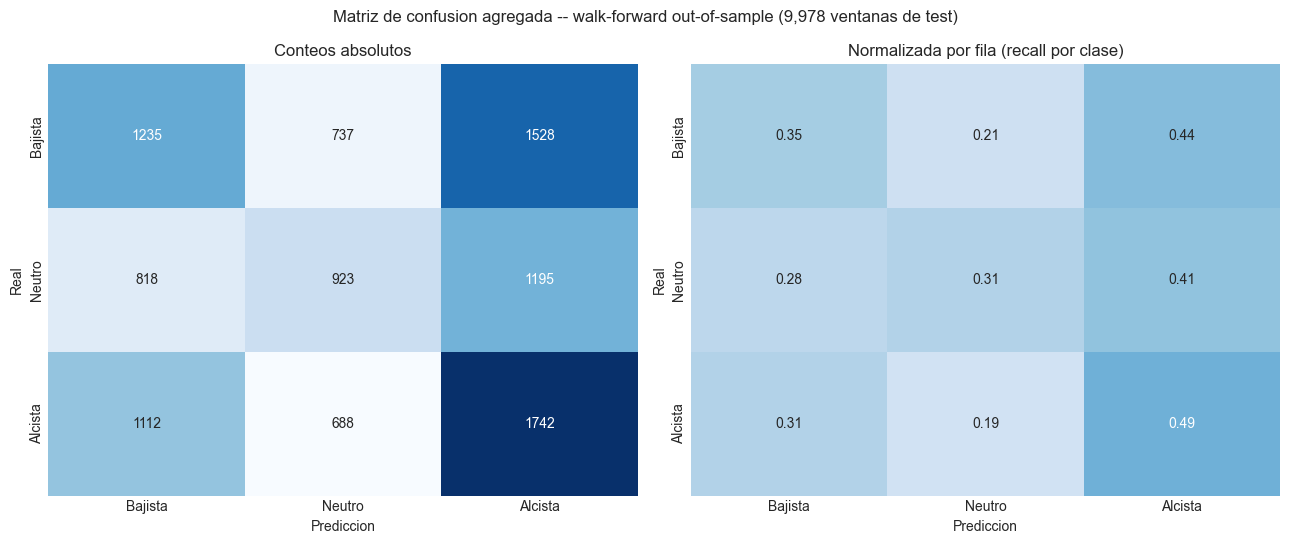

              precision    recall  f1-score   support

     Bajista      0.390     0.353     0.371      3500
      Neutro      0.393     0.314     0.349      2936
     Alcista      0.390     0.492     0.435      3542

    accuracy                          0.391      9978
   macro avg      0.391     0.386     0.385      9978
weighted avg      0.391     0.391     0.387      9978



In [5]:
equity = pl.read_csv(REPORTS_DIR / "walkforward_equity_curve.csv")
y_true = equity["y_true"].to_numpy()
y_pred = equity["y_pred"].to_numpy()

cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[0], cbar=False)
axes[0].set_xlabel("Prediccion")
axes[0].set_ylabel("Real")
axes[0].set_title("Conteos absolutos")

sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[1], cbar=False, vmin=0, vmax=1)
axes[1].set_xlabel("Prediccion")
axes[1].set_ylabel("Real")
axes[1].set_title("Normalizada por fila (recall por clase)")

fig.suptitle(f"Matriz de confusion agregada -- walk-forward out-of-sample ({len(y_true):,} ventanas de test)")
fig.tight_layout()
plt.show()

print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=3))

## 4. PnL simulado con costos de transaccion + slippage

Estrategia trivial derivada directamente de la clase predicha: **Alcista
→ long, Bajista → short, Neutro → flat**. Cada vez que la posicion cambia
de una vela a la siguiente se descuenta un costo de `10 bps`
(`5 bps` de comision taker tipica de Binance spot + `5 bps` de slippage
estimado) -- la unica forma honesta de saber si la senal del modelo, una
vez sale del papel, sigue siendo una ventaja economica real.

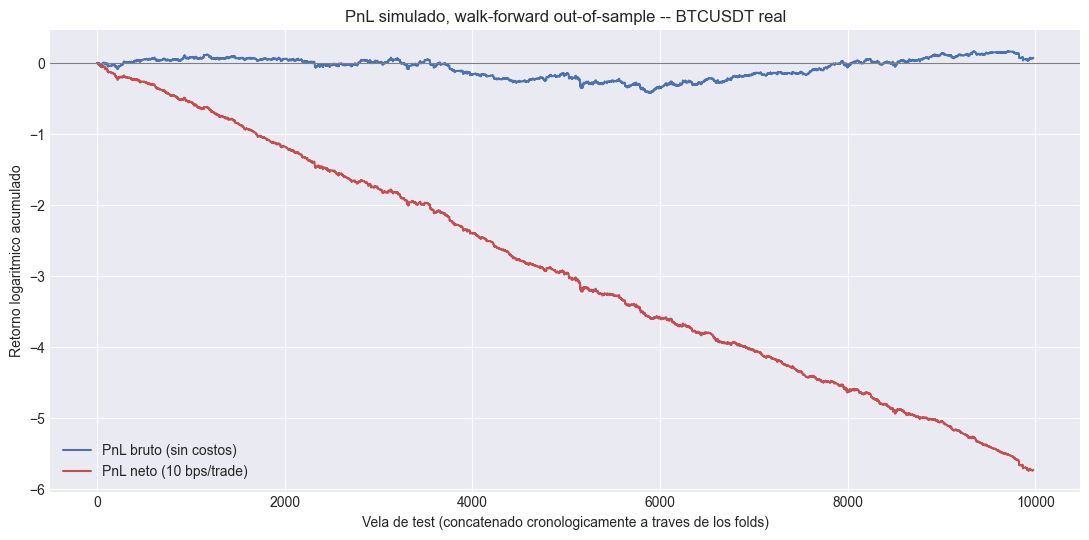

Trades totales: 3,707
PnL bruto total: +0.0733
Costo total pagado: 5.8030
PnL neto total: -5.7297
Sharpe anualizado (neto): -13.24


In [6]:
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(equity["gross_cum"], color=COLOR_GROSS, linewidth=1.5, label="PnL bruto (sin costos)")
ax.plot(equity["net_cum"], color=COLOR_NET, linewidth=1.5,
        label=f"PnL neto ({summary['total_cost_bps']:.0f} bps/trade)")
ax.axhline(0, color="gray", linewidth=0.8)
ax.set_xlabel("Vela de test (concatenado cronologicamente a traves de los folds)")
ax.set_ylabel("Retorno logaritmico acumulado")
ax.set_title("PnL simulado, walk-forward out-of-sample -- BTCUSDT real")
ax.legend()
fig.tight_layout()
plt.show()

print(f"Trades totales: {summary['overall_n_trades']:,}")
print(f"PnL bruto total: {summary['overall_gross_return_total']:+.4f}")
print(f"Costo total pagado: {summary['overall_cost_total']:.4f}")
print(f"PnL neto total: {summary['overall_net_return_total']:+.4f}")
print(f"Sharpe anualizado (neto): {summary['overall_annualized_sharpe_like_net']:.2f}")

## 5. Conclusion

- **La arquitectura Conv1D + Multi-Head Attention recupera una senal por
  encima del azar, pero modesta**: accuracy agregada out-of-sample de
  **39.1%** contra un baseline aleatorio de 3 clases de 33.3% -- una
  mejora real y medida con walk-forward riguroso, no una coincidencia de
  un único split favorable.
- **El PnL bruto (sin costos) es prácticamente plano** (+0.073 en retorno
  logarítmico acumulado sobre ~10.000 velas de test) -- la señal cruda
  apenas roza el punto de equilibrio incluso antes de pagar nada por
  operarla.
- **Una vez se descuentan los costos de transacción y slippage reales
  (10 bps por cambio de posición), el resultado es claramente negativo**
  (-5.730, Sharpe anualizado de -13.2) -- con 3.707 cambios de posición
  sobre ~10.000 velas, el costo acumulado (~5.80) supera ampliamente
  cualquier ventaja bruta que el modelo haya capturado.
- **Esta es exactamente la clase de hallazgo honesto que este proyecto
  busca reportar**: una arquitectura más sofisticada (Conv1D + atención en
  vez de una red densa sobre features tabulares) y una validación más
  rigurosa (walk-forward en vez de un único split) no bastan para convertir
  un patrón estadístico débil en real BTCUSDT en una estrategia rentable
  después de costos -- consistente con la §7.5 de `train_classifier_real.py`,
  que ya mostraba que el edge sintético (φ=0.30 AR(1)) no sobrevive el
  contacto con datos reales, y ahora se confirma que tampoco sobrevive el
  contacto con el costo real de operar.
